# Feature Selection — Mutual Information & MRMR

This notebook performs feature selection on the insurance claims dataset using:
1. **Mutual Information** (sklearn) — measures dependency between features and target
2. **MRMR** (Minimum Redundancy Maximum Relevance) — selects features that are maximally relevant while minimally redundant

**Key methodological choice:** We split the data first and perform all encoding/selection on the training set only to prevent data leakage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
import mrmr
import warnings
warnings.filterwarnings('ignore')

## 1. Load Prepared Data

Data cleaning and feature engineering was done in `data_preparation.ipynb`.

In [2]:
df = pd.read_csv('../data/processed/partially_selected_features.csv')
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()

Shape: (1000, 37)
Missing values: 0


,months_as_customer,age,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_sex,insured_education_level,insured_occupation,...,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,policy_tenure_days,incident_day_of_week,incident_month
0,328,48,OH,250/500,1000,1406.91,0,MALE,MD,craft-repair,...,6510,13020,52080,Saab,92x,2004,Y,100,6,1
1,228,42,IN,250/500,2000,1197.22,5000000,MALE,MD,machine-op-inspct,...,780,780,3510,Mercedes,E400,2007,Y,3130,2,1
2,134,29,OH,100/300,2000,1413.14,5000000,FEMALE,PhD,sales,...,7700,3850,23100,Dodge,RAM,2007,N,5282,6,2
3,256,41,IL,250/500,2000,1415.74,6000000,FEMALE,PhD,armed-forces,...,6340,6340,50720,Chevrolet,Tahoe,2014,Y,8996,5,1
4,228,44,IL,500/1000,1000,1583.91,6000000,MALE,Associate,sales,...,1300,650,4550,Accura,RSX,2009,N,256,1,2


## 2. Train/Val/Test Split (Before Any Encoding)

We split **before** encoding to prevent data leakage. Feature selection will only see training data.

In [3]:
target_col = 'fraud_reported'
y = (df[target_col] == 'Y').astype(int)
X = df.drop(columns=[target_col])

categorical_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical features: {len(categorical_cols)}")
print(f"Numerical features: {len(numerical_cols)}")

# 70/15/15 stratified split (same as model notebooks)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)

print(f"\nTrain: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")
print(f"Train fraud rate: {y_train.mean():.3f}")
print(f"Val fraud rate:   {y_val.mean():.3f}")
print(f"Test fraud rate:  {y_test.mean():.3f}")

Categorical features: 17
Numerical features: 19

Train: 699 | Val: 151 | Test: 150
Train fraud rate: 0.247
Val fraud rate:   0.245
Test fraud rate:  0.247


## 3. One-Hot Encode on Training Set Only

We use one-hot encoding (not label encoding) to avoid imposing false ordinal relationships on nominal features. Encoders are fit on training data only.

In [4]:
# One-hot encode training data
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=False, dtype=int)

print(f"Training set after one-hot encoding: {X_train_encoded.shape}")
print(f"Original features: {len(categorical_cols)} categorical + {len(numerical_cols)} numerical = {len(categorical_cols) + len(numerical_cols)}")
print(f"After one-hot: {X_train_encoded.shape[1]} columns")

Training set after one-hot encoding: (699, 162)
Original features: 17 categorical + 19 numerical = 36
After one-hot: 162 columns


## 4. Mutual Information Feature Selection

MI is computed on the one-hot encoded training set. Each dummy variable gets its own MI score, showing which specific category levels are informative.

In [5]:
# All features are now numeric; no need for discrete_features mask
mi_scores = mutual_info_classif(
    X_train_encoded, y_train,
    random_state=42,
    n_neighbors=5
)

mi_df = pd.DataFrame({
    'Feature': X_train_encoded.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False).reset_index(drop=True)

print("Top 30 Mutual Information Scores:")
print("=" * 55)
for _, row in mi_df.head(30).iterrows():
    bar = '#' * int(row['MI_Score'] * 100)
    print(f"{row['Feature']:<45} {row['MI_Score']:.4f}  {bar}")

Top 30 Mutual Information Scores:
incident_severity_Major Damage                0.1316  #############
insured_education_level_JD                    0.0320  ###
incident_type_Multi-vehicle Collision         0.0307  ###
incident_severity_Minor Damage                0.0300  ###
auto_make_Volkswagen                          0.0286  ##
insured_hobbies_cross-fit                     0.0263  ##
incident_state_SC                             0.0235  ##
property_claim                                0.0235  ##
insured_education_level_Masters               0.0231  ##
incident_severity_Total Loss                  0.0229  ##
total_claim_amount                            0.0228  ##
insured_hobbies_chess                         0.0220  ##
insured_occupation_craft-repair               0.0217  ##
auto_make_Toyota                              0.0211  ##
vehicle_claim                                 0.0210  ##
auto_model_Maxima                             0.0209  ##
auto_make_Chevrolet                     

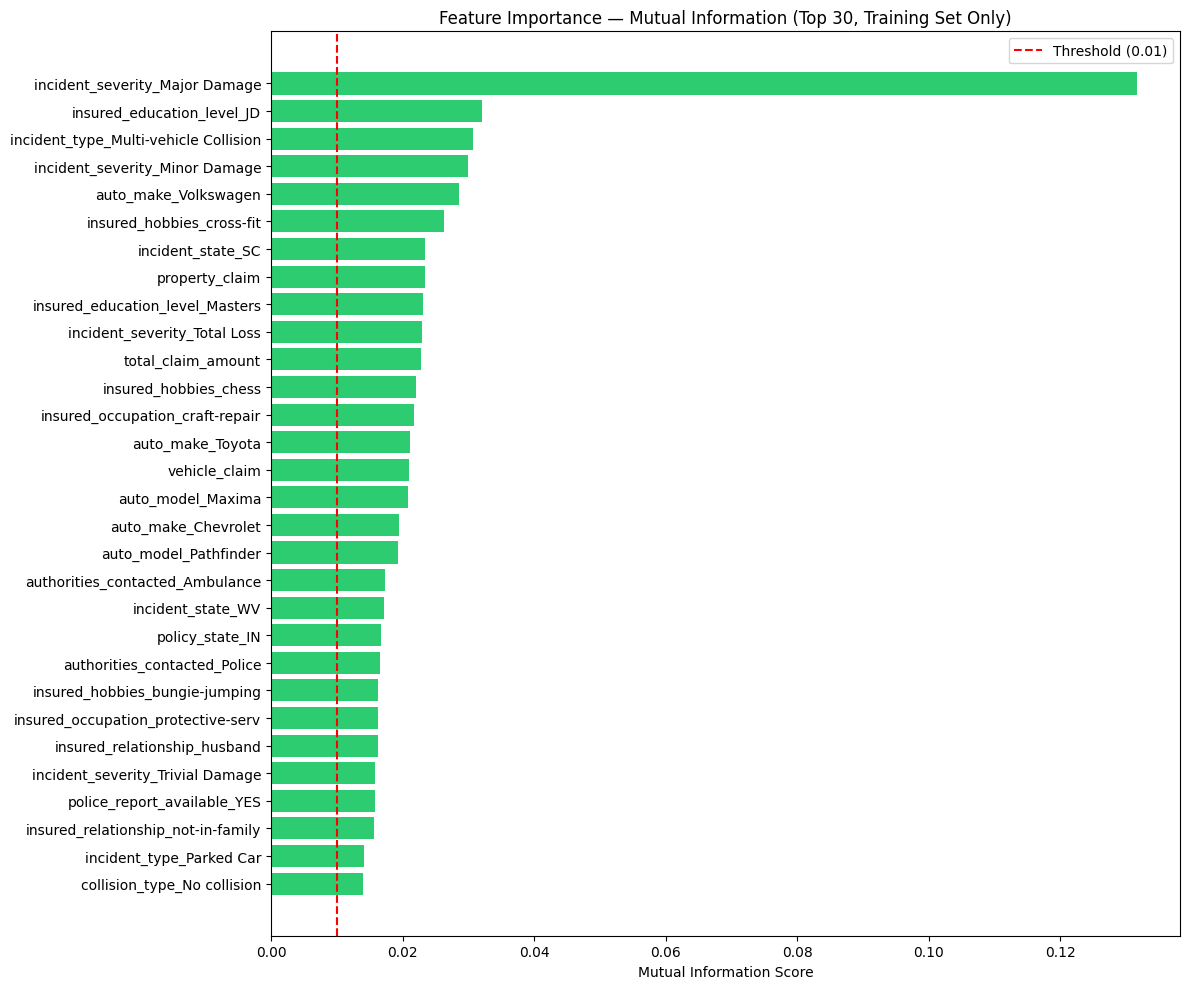

In [6]:
# Visualize MI scores (top 30 for readability)
mi_top30 = mi_df.head(30)
plt.figure(figsize=(12, 10))
colors = ['#2ecc71' if score > 0.01 else '#e74c3c' for score in mi_top30['MI_Score']]
plt.barh(range(len(mi_top30)), mi_top30['MI_Score'], color=colors)
plt.yticks(range(len(mi_top30)), mi_top30['Feature'])
plt.xlabel('Mutual Information Score')
plt.title('Feature Importance — Mutual Information (Top 30, Training Set Only)')
plt.axvline(x=0.01, color='red', linestyle='--', label='Threshold (0.01)')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. MRMR Feature Selection

MRMR selects features that have high relevance to the target but low redundancy among themselves. Applied on one-hot encoded training data.

Since one-hot encoding expands a single categorical feature into multiple dummies, we select K=50 one-hot features to ensure we cover enough distinct original columns (~20). The dummies are then mapped back to their original feature names.

In [7]:
# Run MRMR on the one-hot encoded training set
# K=50 one-hot features to cover ~20 original columns (categorical features expand into many dummies)
n_ohe_to_select = 50

selected_features_mrmr = mrmr.mrmr_classif(
    X=X_train_encoded,
    y=y_train,
    K=n_ohe_to_select,
    show_progress=False
)

print(f"MRMR Selected Features (top {n_ohe_to_select} one-hot features):")
print("=" * 60)
for i, feat in enumerate(selected_features_mrmr, 1):
    mi_score = mi_df[mi_df['Feature'] == feat]['MI_Score'].values[0]
    print(f"{i:>2}. {feat:<45} (MI: {mi_score:.4f})")

MRMR Selected Features (top 50 one-hot features):
 1. incident_severity_Major Damage                (MI: 0.1316)
 2. insured_hobbies_chess                         (MI: 0.0220)
 3. insured_hobbies_cross-fit                     (MI: 0.0263)
 4. incident_severity_Minor Damage                (MI: 0.0300)
 5. insured_occupation_transport-moving           (MI: 0.0026)
 6. incident_state_WV                             (MI: 0.0172)
 7. vehicle_claim                                 (MI: 0.0210)
 8. auto_model_Civic                              (MI: 0.0091)
 9. auto_model_Malibu                             (MI: 0.0000)
10. auto_model_F150                               (MI: 0.0060)
11. incident_severity_Total Loss                  (MI: 0.0229)
12. auto_model_X6                                 (MI: 0.0064)
13. insured_hobbies_golf                          (MI: 0.0000)
14. auto_model_Legacy                             (MI: 0.0023)
15. collision_type_No collision                   (MI: 0.0140)
16. i

In [8]:
# Compare MI ranking vs MRMR ranking (top 20 from each for readability)
mi_top20 = mi_df.head(20)['Feature'].tolist()
mrmr_top20 = selected_features_mrmr[:20]

print("Comparison: MI vs MRMR Rankings (top 20)")
print("=" * 85)
print(f"{'Rank':<6} {'MI Top Features':<45} {'MRMR Top Features':<45}")
print("-" * 85)
for i in range(20):
    mi_feat = mi_top20[i] if i < len(mi_top20) else '-'
    mrmr_feat = mrmr_top20[i] if i < len(mrmr_top20) else '-'
    marker = ' *' if mi_feat != mrmr_feat else ''
    print(f"{i+1:<6} {mi_feat:<45} {mrmr_feat:<45}{marker}")

common = set(mi_top20) & set(mrmr_top20)
print(f"\nOverlap in top 20: {len(common)} features")

Comparison: MI vs MRMR Rankings (top 20)
Rank   MI Top Features                               MRMR Top Features                            
-------------------------------------------------------------------------------------
1      incident_severity_Major Damage                incident_severity_Major Damage               
2      insured_education_level_JD                    insured_hobbies_chess                         *
3      incident_type_Multi-vehicle Collision         insured_hobbies_cross-fit                     *
4      incident_severity_Minor Damage                incident_severity_Minor Damage               
5      auto_make_Volkswagen                          insured_occupation_transport-moving           *
6      insured_hobbies_cross-fit                     incident_state_WV                             *
7      incident_state_SC                             vehicle_claim                                 *
8      property_claim                                auto_model_Civic  

## 6. Map Back to Original Feature Names

Since we used one-hot encoding, some selected features are dummies like `auto_make_Saab`. We need to map these back to their original column names so downstream model notebooks can apply their own encoding.

In [9]:
# Map one-hot feature names back to original column names
def get_original_feature(ohe_name, original_categoricals, original_numericals):
    """Map a one-hot encoded feature name back to its original column."""
    if ohe_name in original_numericals:
        return ohe_name
    for cat_col in original_categoricals:
        if ohe_name == cat_col or ohe_name.startswith(cat_col + '_'):
            return cat_col
    return ohe_name

# Get unique original features from MRMR selection
selected_original = []
seen = set()
for feat in selected_features_mrmr:
    orig = get_original_feature(feat, categorical_cols, numerical_cols)
    if orig not in seen:
        selected_original.append(orig)
        seen.add(orig)

print(f"MRMR selected {n_ohe_to_select} one-hot features mapping to {len(selected_original)} original columns:")
print("=" * 60)
for i, feat in enumerate(selected_original, 1):
    feat_type = 'categorical' if feat in categorical_cols else 'numerical'
    ohe_selected = [f for f in selected_features_mrmr if get_original_feature(f, categorical_cols, numerical_cols) == feat]
    print(f"{i:>2}. {feat:<35} ({feat_type:<12}) [{len(ohe_selected)} dummy/ies selected]")

final_features = selected_original

MRMR selected 50 one-hot features mapping to 17 original columns:
 1. incident_severity                   (categorical ) [4 dummy/ies selected]
 2. insured_hobbies                     (categorical ) [10 dummy/ies selected]
 3. insured_occupation                  (categorical ) [4 dummy/ies selected]
 4. incident_state                      (categorical ) [4 dummy/ies selected]
 5. vehicle_claim                       (numerical   ) [1 dummy/ies selected]
 6. auto_model                          (categorical ) [13 dummy/ies selected]
 7. collision_type                      (categorical ) [1 dummy/ies selected]
 8. insured_relationship                (categorical ) [1 dummy/ies selected]
 9. total_claim_amount                  (numerical   ) [1 dummy/ies selected]
10. authorities_contacted               (categorical ) [2 dummy/ies selected]
11. incident_type                       (categorical ) [2 dummy/ies selected]
12. property_claim                      (numerical   ) [1 dummy/ies select

## 7. Save Selected Features

We save the dataset with original (unencoded) selected features + target. Downstream model notebooks will apply their own encoding.

In [10]:
# Save selected features (original unencoded columns + target)
selected_df = df[final_features + [target_col]]
selected_df.to_csv('../data/processed/selected_features.csv', index=False)
print(f"Saved selected features dataset to data/processed/selected_features.csv")
print(f"Shape: {selected_df.shape}")
print(f"\nFinal selected features ({len(final_features)}):")
for i, f in enumerate(final_features, 1):
    print(f"  {i}. {f}")

Saved selected features dataset to data/processed/selected_features.csv
Shape: (1000, 18)

Final selected features (17):
  1. incident_severity
  2. insured_hobbies
  3. insured_occupation
  4. incident_state
  5. vehicle_claim
  6. auto_model
  7. collision_type
  8. insured_relationship
  9. total_claim_amount
  10. authorities_contacted
  11. incident_type
  12. property_claim
  13. auto_make
  14. incident_city
  15. bodily_injuries
  16. umbrella_limit
  17. injury_claim


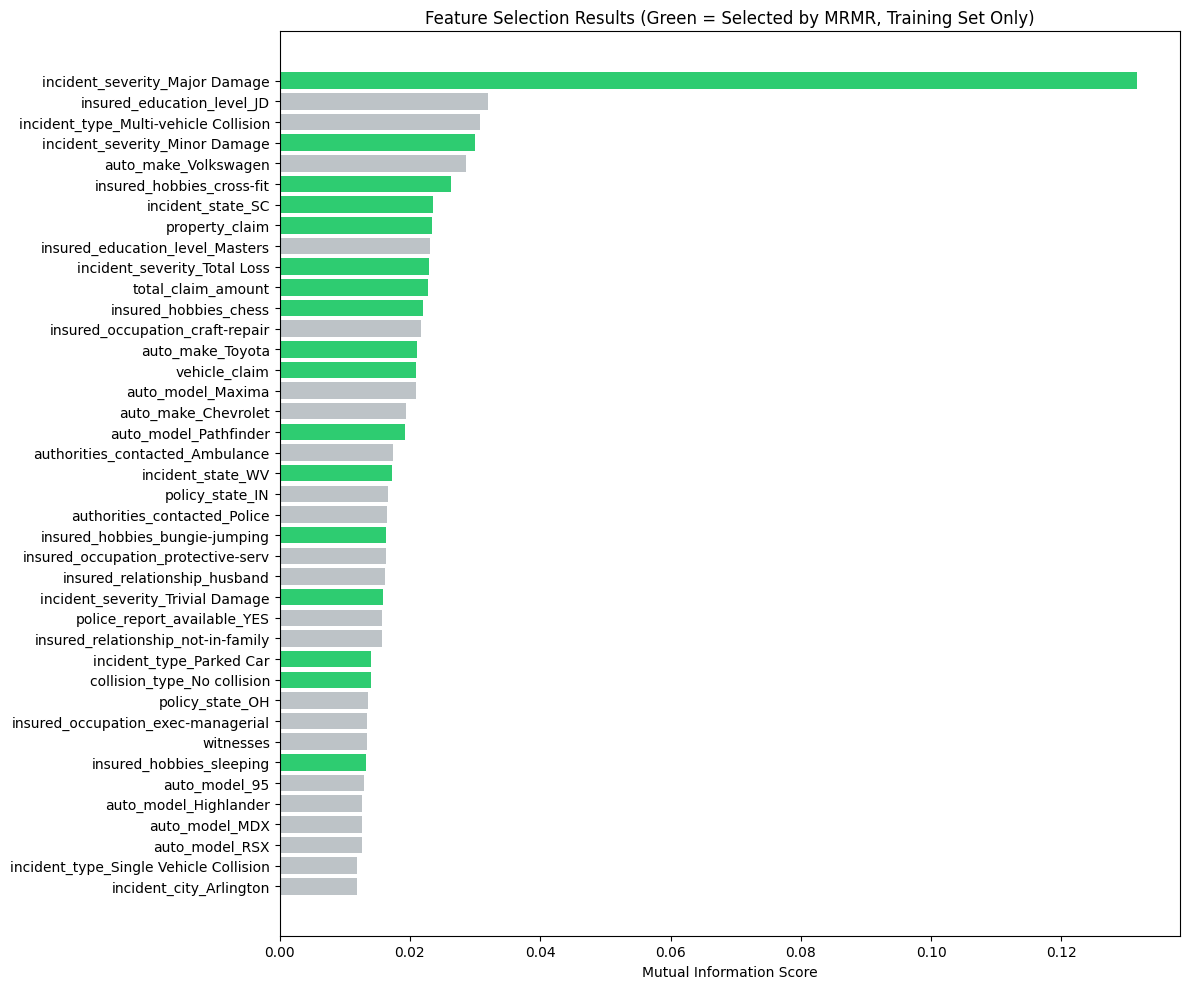


Selected: 50 one-hot features -> 17 original columns
Dropped: 112 one-hot features


In [11]:
# Visualize: MI scores colored by MRMR selection
mi_df['Selected'] = mi_df['Feature'].isin(selected_features_mrmr)

plt.figure(figsize=(12, 10))
mi_plot = mi_df.head(40)  # Show top 40 for readability
colors = ['#2ecc71' if sel else '#bdc3c7' for sel in mi_plot['Selected']]
plt.barh(range(len(mi_plot)), mi_plot['MI_Score'], color=colors)
plt.yticks(range(len(mi_plot)), mi_plot['Feature'])
plt.xlabel('Mutual Information Score')
plt.title('Feature Selection Results (Green = Selected by MRMR, Training Set Only)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

dropped = [f for f in X_train_encoded.columns if f not in selected_features_mrmr]
print(f"\nSelected: {len(selected_features_mrmr)} one-hot features -> {len(final_features)} original columns")
print(f"Dropped: {len(dropped)} one-hot features")